In [1]:
import torch
import math

from src.knots import *
from src.extensions import *
from src.full_models import HyperbolicMinimalSurfacePINN
from src.plotting import plot_error, plot_knot, montecarlo_error, plot_mu_heatmap_log
from src.geometry import minimal_in_H4_PDE_flat_new
from src.samplers import MixSampler
from src.training import train_PINN_Adam, refine_PINN_lbfgs
from src.double_point_analysis import find_candidate_double_points, refine_double_points_newton
from src.interior_models import MLP

from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget

## Load a pre-trained model

Pre-trained checkpoints live in `trained_models/`. Uncomment the file you want to inspect and re-run the cell.

In [ ]:
# load the model
trained_models_path = 'trained_models/models/paper/'
knot_type = 'stevedore' #'torus'
knot_parameters = 'R1.6_mirrorFalse' #'R1_p3_q2_r0.5'
perturbed = True

model_name = trained_models_path + 'KNOT_' + knot_type + '_KNOT_PAR_' + knot_parameters
if perturbed:
    model_name += '_PERTURBED.pt'
else:
    model_name += '.pt'

model = HyperbolicMinimalSurfacePINN.load(model_name)

## Plot the boundary knot

The curve $\gamma(\theta) \subset \mathbb{R}^3$ that the trained minimal surface bounds at $\partial D^2$.

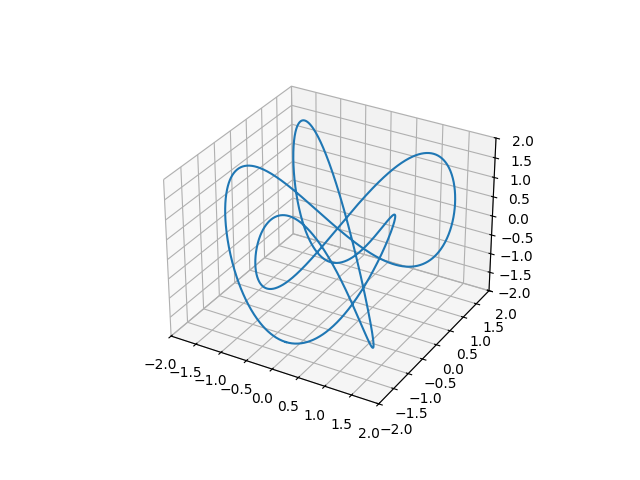

In [3]:
# show the knot
knot_evaluator = model.get_knot().get_evaluator()
plot_knot(knot_evaluator, dtype=model.kwargs['dtype'])

## Error statistics

Two views of the trained surface:

1. Mean squared $L^2$ error of the PDE residual and its pointwise max on a random sample.
2. A 2D heatmap of $\|t(x)\|^2$ over the disc — useful for spotting where the network is least accurate.

In [4]:
# Same diagnostics on a freshly instantiated (UNTRAINED) model with the
# same architecture — shown here as a baseline before training.
untrained_model = HyperbolicMinimalSurfacePINN(**model.kwargs)

sampler = MixSampler(target=(0.2, 0.03), mix=0.7, bias=0.5, sigma=0.3, dtype=untrained_model.kwargs['dtype'])

xy = sampler(1000)
t = minimal_in_H4_PDE_flat_new(untrained_model)(xy)

print('Max pointwise norm of the tension field:', torch.max((t**2).sum(dim=-1)**0.5).detach().item())
print('MSE:', (t**2).sum(dim=-1).mean().detach().item())

Max pointwise norm of the tension field: 639.8796611368471
MSE: 912.5519606244063


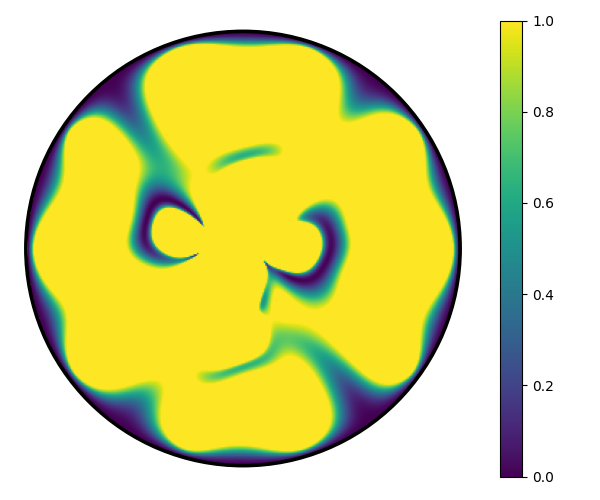

In [5]:
# plot the error on a regular grid
plot_error(
    minimal_in_H4_PDE_flat_new(untrained_model),
    dtype=untrained_model.kwargs['dtype'],
    vmin=0,
    vmax=1,
    grid_size=300,
    boundary_linewidth=2.6,
    figsize=(6,5),
    colorbar_label='',
    title=None)

In [6]:
# compute the squared L2 error and the max of the pointwise norm of the tension field
sampler = MixSampler(target=(0.2, 0.03), mix=0.7, bias=0.5, sigma=0.3, dtype=model.kwargs['dtype'])

xy = sampler(1000)
t = minimal_in_H4_PDE_flat_new(model)(xy)

print('Max pointwise norm of the tension field:', torch.max((t**2).sum(dim=-1)**0.5).detach().item())
print('MSE:', (t**2).sum(dim=-1).mean().detach().item())

Max pointwise norm of the tension field: 0.013824032180641727
MSE: 4.059671440005704e-06


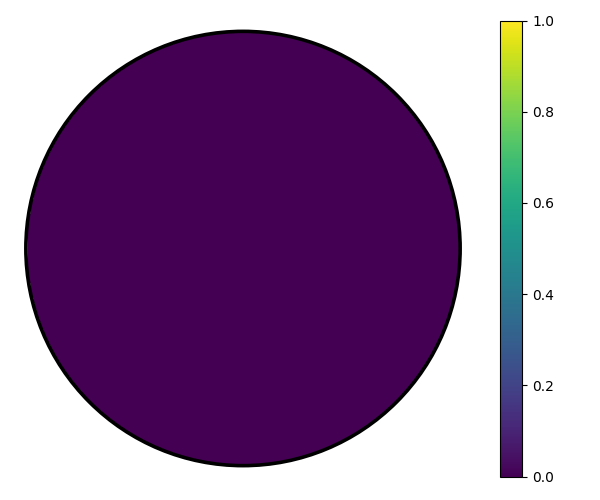

In [7]:
plot_error(
    minimal_in_H4_PDE_flat_new(model),
    dtype=untrained_model.kwargs['dtype'],
    vmin=0,
    vmax=1,
    grid_size=300,
    boundary_linewidth=2.6,
    figsize=(6,5),
    colorbar_label='',
    title=None)

In [8]:
# montecarlo_error(
#     minimal_in_H4_PDE_flat_new(model),
#     num_samples=1000,
#     size_samples=2**14,
#     figsize=(5,3),
#     bins=100,
#     title=None,
#     xlabel = 'Loss'
# )

## Self-proximity map

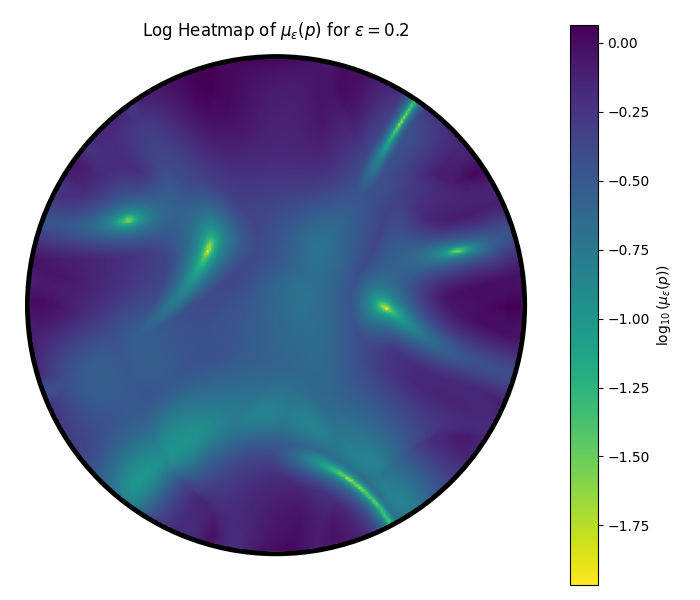

<Axes: title={'center': 'Log Heatmap of $\\mu_{\\varepsilon}(p)$ for $\\varepsilon = 0.2$'}>

In [9]:
plot_mu_heatmap_log(
    model,
    epsilon=0.2,
    candidates=None,
    grid_resolution=200,
)

In [10]:
candidates = find_candidate_double_points(
    model,
    grid_resolution=200,
    epsilon=0.2,
    tau=0.03,
    dtype=model.kwargs['dtype'])

candidates

tensor([[[-0.5980,  0.3367],
         [ 0.7286,  0.2161]],

        [[-0.5980,  0.3467],
         [ 0.7387,  0.2161]],

        [[-0.2864,  0.1960],
         [ 0.4573, -0.0151]],

        [[-0.2864,  0.2060],
         [ 0.4573, -0.0151]],

        [[-0.2764,  0.2060],
         [ 0.4472, -0.0151]],

        [[-0.2764,  0.2161],
         [ 0.4472, -0.0151]],

        [[-0.2764,  0.2261],
         [ 0.4372, -0.0050]],

        [[-0.2764,  0.2362],
         [ 0.4372, -0.0050]],

        [[-0.2663,  0.2261],
         [ 0.4372, -0.0151]],

        [[-0.2663,  0.2362],
         [ 0.4372, -0.0050]],

        [[-0.2663,  0.2462],
         [ 0.4271, -0.0050]],

        [[ 0.2563, -0.6784],
         [ 0.4874,  0.7085]],

        [[ 0.2864, -0.6985],
         [ 0.4975,  0.7286]],

        [[ 0.2965, -0.7085],
         [ 0.4975,  0.7286]],

        [[ 0.3065, -0.7085],
         [ 0.5075,  0.7387]],

        [[ 0.3166, -0.7186],
         [ 0.5075,  0.7387]],

        [[ 0.3266, -0.7286],
         [ 

In [11]:
refined_pairs, jacobians, final_distances = refine_double_points_newton(
    model,
    candidates,
    tol=1e-14,
    max_iter=200,
    dedup_tol=1e-11,
    dtype=model.kwargs['dtype'],
)

In [12]:
refined_pairs

[(tensor([-0.5980,  0.3423], dtype=torch.float64),
  tensor([0.7326, 0.2181], dtype=torch.float64)),
 (tensor([-0.2737,  0.2243], dtype=torch.float64),
  tensor([ 0.4416, -0.0104], dtype=torch.float64)),
 (tensor([ 0.3110, -0.7147], dtype=torch.float64),
  tensor([0.5075, 0.7423], dtype=torch.float64))]

In [13]:
jacobians

[218.1625012849469, 32.295310991711446, -51.46302204749005]

In [14]:
final_distances

[8.125323285481904e-16, 1.8610729195778454e-15, 4.379755957367587e-16]

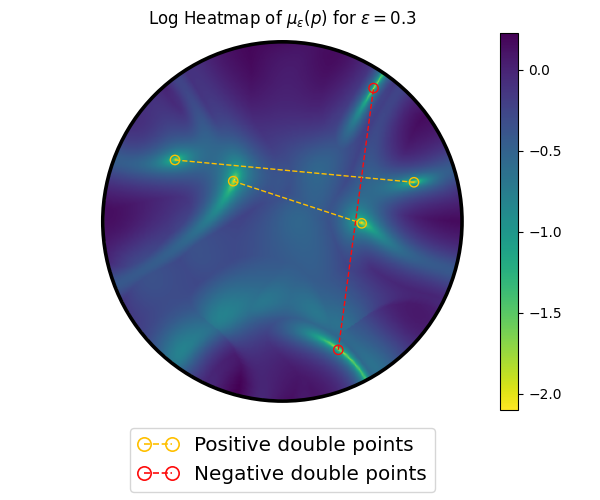

<Axes: title={'center': 'Log Heatmap of $\\mu_{\\varepsilon}(p)$ for $\\varepsilon = 0.3$'}>

In [15]:
# Bundle A - color
plot_mu_heatmap_log(
    # --- Main settings
    u_callable = model,
    epsilon = 0.3,
    cmap='viridis_r',
    grid_resolution=300,
    figsize=(6,5),
    # title = None,

    # # --- Candidate Settings ---
    # candidates=candidates,
    # candidate_color="#E85D04",
    # alpha = 0.8,

    # --- Refined pairs Settings ---
    refined_pairs=refined_pairs,
    jacobians=jacobians,
    refined_pos_color='#ffc000',
    refined_neg_color="#fe0c0c",

    # --- Legend Settings ---
    # legend_title = 'Double points',
    legend_label_candidates='Candidate double points',
    legend_label_refined_pos=r'Positive double points',
    legend_label_refined_neg=r'Negative double points',
    # legend_bbox_to_anchor=None,
    # legend_loc='upper right',
    legend_frameon=True,

    # --- Boundary Settings ---
    boundary_color='black', 
    boundary_linewidth=2.6,

    # --- Colorbar Settings ---
    show_colorbar=True,
    colorbar_label=None,
)

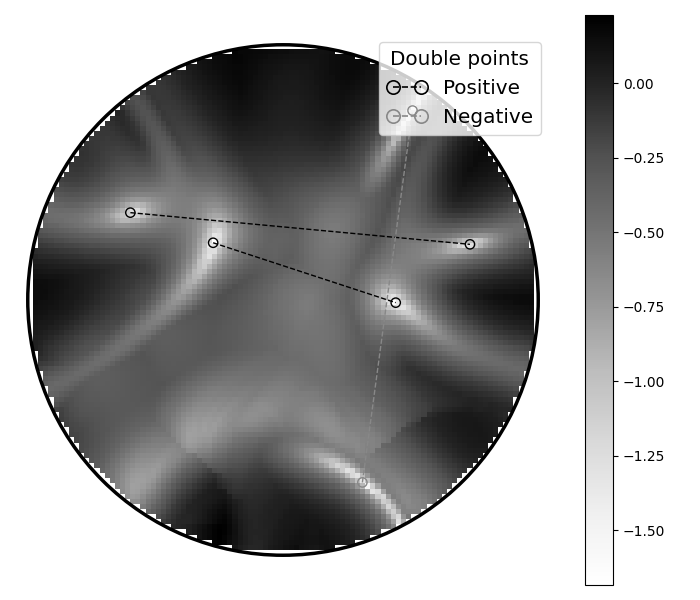

<Axes: >

In [16]:
# Bundle A - greyscale
plot_mu_heatmap_log(
    # --- Main settings
    u_callable = model,
    epsilon = 0.3,
    cmap='Greys',
    grid_resolution=100,
    title = None,

    # # --- Candidate Settings ---
    # candidates=candidates,
    # candidate_color="#5B5A5A",
    # alpha = 0.5,
    # legend_label_candidates='Candidate pairs',

    # --- Refined pairs Settings ---
    refined_pairs=refined_pairs,
    jacobians=jacobians,
    refined_pos_color="#000000",
    refined_neg_color="#888888",

    # --- Legend Settings ---
    legend_title = 'Double points',
    legend_label_candidates='Candidate',
    legend_label_refined_pos=r'Positive',
    legend_label_refined_neg=r'Negative',
    legend_bbox_to_anchor=None,
    legend_loc='upper right',
    legend_frameon=True,

    # --- Boundary Settings ---
    boundary_color='black', 
    boundary_linewidth=2.5,

    # --- Other Settings ---
    colorbar_label=None,
)

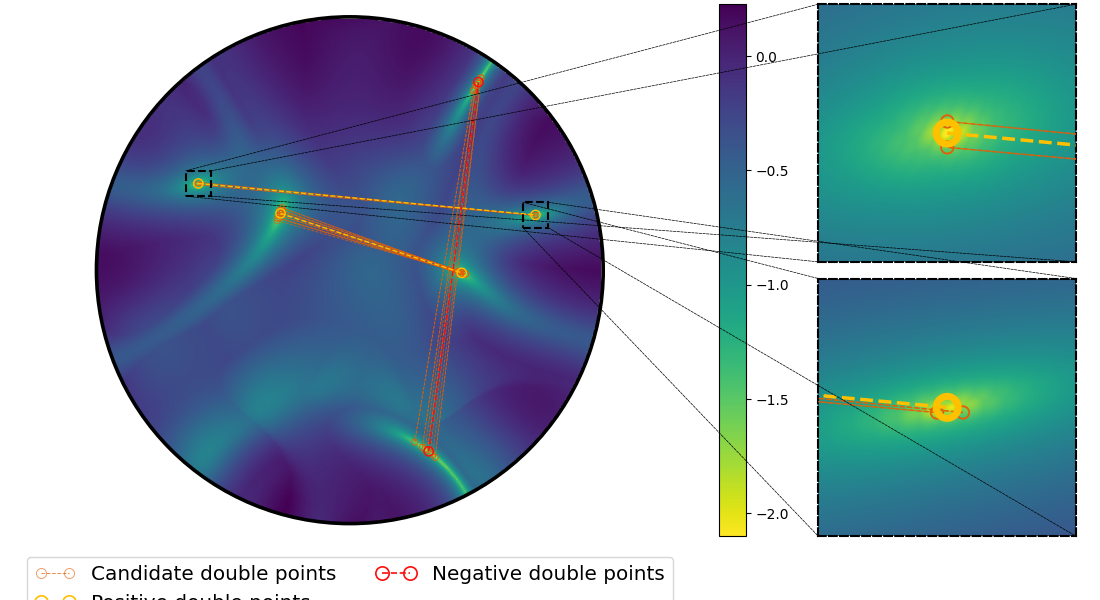

In [17]:
# ONLY FOR TREFOIL - NOT FOR THE PUBLIC REPO 
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch

# --- Extract refined pair endpoints (the two zoom centers) ---
p_refined, q_refined = refined_pairs[0]
p_refined = p_refined.detach().cpu().numpy()
q_refined = q_refined.detach().cpu().numpy()

# --- Heatmap inputs (shared between the main panel and the local heatmaps) ---
compute_kwargs = dict(
    u_callable=model,
    epsilon=0.3,
    cmap='viridis_r',
    grid_resolution=300,
    candidates=candidates,
    refined_pairs=refined_pairs,
    jacobians=jacobians,
)

# --- Main panel styling (kept identical to the previous cell) ---
main_panel_kwargs = dict(
    candidate_color="#E85D04",
    alpha=0.8,
    refined_pos_color='#ffc000',
    refined_neg_color='#fe0c0c',
    boundary_color='black',
    boundary_linewidth=2.6,
    title=None,
    colorbar_label=None,
    legend_label_candidates='Candidate double points',
    legend_label_refined_pos=r'Positive double points',
    legend_label_refined_neg=r'Negative double points',
    legend_frameon=True,
    legend_ncols=2,
    show_colorbar=True,
)

# Font size applied to the main panel's legend after the function call
# (plot_mu_heatmap_log does not expose a legend_fontsize parameter).
legend_fontsize = 14

# =====================================================================
# === ZOOM PANELS — everything visual is editable below ===============
# =====================================================================

# ---- Geometry / resolution ----
zoom_radius = 0.05               # half-width of each zoom box (domain units)
zoom_heatmap_resolution = 200    # pixels per side for the LOCAL heatmap
zoom_disc_resolution = 300       # disc sample density used for mu_eps

# ---- Local heatmap imshow kwargs.
#      vmin / vmax default to the main panel's range; add them here to override.
zoom_heatmap_kwargs = dict(
    cmap='viridis_r',
    cmap_bad_color='white',
    origin='lower',
    interpolation='bilinear',
)

# ---- Candidate dots ----
zoom_candidate_scatter_kwargs = dict(
    s=80,
    facecolor='none',
    edgecolor="#E85D04",
    linewidth=1.2,
    alpha=0.8,
    zorder=4,
)

# ---- Candidate connecting lines ----
zoom_candidate_line_kwargs = dict(
    color="#E85D04",
    linestyle='--',
    linewidth=1.0,
    alpha=0.8,
    zorder=3,
)

# ---- Refined pair sign colors ----
zoom_refined_pos_color = '#ffc000'
zoom_refined_neg_color = '#a40e26'

# ---- Refined dots (edgecolor injected per sign) ----
zoom_refined_scatter_kwargs = dict(
    s=250,
    facecolor='none',
    linewidth=5.0,
    zorder=6,
)

# ---- Refined connecting lines (color injected per sign) ----
zoom_refined_line_kwargs = dict(
    linestyle='--',
    linewidth=2.5,
    zorder=5,
)

# ---- Dashed frame around each zoom panel (rendered via the panel's spines) ----
zoom_frame_kwargs = dict(
    edgecolor='black',
    linewidth=1.5,
    linestyle='--',
)

# ---- Dashed rectangle drawn inside the disc, marking each zoom region ----
zoom_rect_kwargs = dict(
    edgecolor='black',
    linewidth=1.5,
    linestyle='--',
)

# ---- Dashed leader lines from disc-rect corners to zoom-frame corners ----
zoom_connector_kwargs = dict(
    color='black',
    linestyle='--',
    linewidth=0.5,
    zorder=10,
)



# =====================================================================


def _local_log_mu_eps(model, epsilon, box, zoom_res, disc_res,
                      batch_size=2000, dtype=torch.float64, device='cpu'):
    """log10(mu_eps) on a fine grid inside `box`, sampling the unit disc at
    `disc_res` per side to find the minimum-distance pair."""
    x_min, x_max, y_min, y_max = box

    # Disc reference samples
    xd = torch.linspace(-1.0, 1.0, disc_res, dtype=dtype, device=device)
    yd = torch.linspace(-1.0, 1.0, disc_res, dtype=dtype, device=device)
    Xd, Yd = torch.meshgrid(xd, yd, indexing='xy')
    d_pts = torch.stack([Xd.flatten(), Yd.flatten()], dim=1)
    q_pts = d_pts[(d_pts[:, 0] ** 2 + d_pts[:, 1] ** 2) <= 1.0]

    # Zoom grid
    xz = torch.linspace(x_min, x_max, zoom_res, dtype=dtype, device=device)
    yz = torch.linspace(y_min, y_max, zoom_res, dtype=dtype, device=device)
    Xz, Yz = torch.meshgrid(xz, yz, indexing='xy')
    p_pts = torch.stack([Xz.flatten(), Yz.flatten()], dim=1)
    M = p_pts.shape[0]

    with torch.no_grad():
        u_q = model(q_pts)
        u_p = model(p_pts)

    mu = torch.empty(M, dtype=dtype, device=device)
    for i in range(0, M, batch_size):
        p_b = p_pts[i:i + batch_size]
        u_b = u_p[i:i + batch_size]
        dp = torch.cdist(p_b, q_pts)
        du = torch.cdist(u_b, u_q)
        du[dp <= epsilon] = float('inf')
        bm, _ = torch.min(du, dim=1)
        mu[i:i + batch_size] = bm
    mu[torch.isinf(mu)] = float('nan')
    return np.log10(mu.view(zoom_res, zoom_res).cpu().numpy())


# --- Figure layout ---
fig = plt.figure(figsize=(11, 6), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[1.8, 1])
ax_main = fig.add_subplot(gs[:, 0])
ax_zoom_p = fig.add_subplot(gs[0, 1])
ax_zoom_q = fig.add_subplot(gs[1, 1])

# --- Main heatmap (full disc, via the function) ---
plot_mu_heatmap_log(**compute_kwargs, **main_panel_kwargs, ax=ax_main)


# Default zoom-heatmap color range = main panel's range
main_im = ax_main.images[0]
default_vmin = main_im.norm.vmin
default_vmax = main_im.norm.vmax

# Pre-extract candidate / refined arrays as numpy
candidate_pairs_np = candidates.detach().cpu().numpy()
refined_pairs_np = [
    (p.detach().cpu().numpy(), q.detach().cpu().numpy())
    for p, q in refined_pairs
]

# --- Render the two zoom panels ---
for ax_zoom, center in [
    (ax_zoom_p, p_refined),
    (ax_zoom_q, q_refined),
]:
    x_min = center[0] - zoom_radius
    x_max = center[0] + zoom_radius
    y_min = center[1] - zoom_radius
    y_max = center[1] + zoom_radius

    # Local smooth heatmap
    log_mu = _local_log_mu_eps(
        model, compute_kwargs['epsilon'],
        (x_min, x_max, y_min, y_max),
        zoom_res=zoom_heatmap_resolution,
        disc_res=zoom_disc_resolution,
    )

    # imshow with vmin/vmax matched to the main panel by default
    cmap_obj = plt.colormaps[zoom_heatmap_kwargs['cmap']].with_extremes(
        bad=zoom_heatmap_kwargs.get('cmap_bad_color', 'white'))
    vmin = zoom_heatmap_kwargs.get('vmin', default_vmin)
    vmax = zoom_heatmap_kwargs.get('vmax', default_vmax)
    imshow_other = {
        k: v for k, v in zoom_heatmap_kwargs.items()
        if k not in ('cmap', 'cmap_bad_color', 'vmin', 'vmax')
    }
    ax_zoom.imshow(
        log_mu,
        extent=[x_min, x_max, y_min, y_max],
        cmap=cmap_obj,
        vmin=vmin, vmax=vmax,
        **imshow_other,
    )

    # Panel limits / aspect
    ax_zoom.set_xlim(x_min, x_max)
    ax_zoom.set_ylim(y_min, y_max)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.set_aspect('equal', adjustable='box')

    # Candidate dots and lines (lines naturally clip to the panel -> short stubs)
    for p_c, q_c in candidate_pairs_np:
        ax_zoom.scatter([p_c[0], q_c[0]], [p_c[1], q_c[1]],
                        **zoom_candidate_scatter_kwargs)
        ax_zoom.plot([p_c[0], q_c[0]], [p_c[1], q_c[1]],
                     **zoom_candidate_line_kwargs)

    # Refined dots and lines (sign-coloured)
    for i, (p_np, q_np) in enumerate(refined_pairs_np):
        color = (zoom_refined_pos_color
                 if jacobians[i] > 0 else zoom_refined_neg_color)
        ax_zoom.scatter([p_np[0], q_np[0]], [p_np[1], q_np[1]],
                        edgecolor=color, **zoom_refined_scatter_kwargs)
        ax_zoom.plot([p_np[0], q_np[0]], [p_np[1], q_np[1]],
                     color=color, **zoom_refined_line_kwargs)

    # Dashed frame around the zoom panel (via the panel's spines)
    for spine in ax_zoom.spines.values():
        spine.set_edgecolor(zoom_frame_kwargs['edgecolor'])
        spine.set_linewidth(zoom_frame_kwargs['linewidth'])
        spine.set_linestyle(zoom_frame_kwargs['linestyle'])

# --- Disc-rect markers + corner connectors ---
for ax_zoom, center in [(ax_zoom_p, p_refined), (ax_zoom_q, q_refined)]:
    x_min = center[0] - zoom_radius
    x_max = center[0] + zoom_radius
    y_min = center[1] - zoom_radius
    y_max = center[1] + zoom_radius

    rect = plt.Rectangle(
        (x_min, y_min), 2 * zoom_radius, 2 * zoom_radius,
        fill=False, zorder=10, **zoom_rect_kwargs,
    )
    ax_main.add_patch(rect)

    for corner in [(x_min, y_max), (x_max, y_max),
                   (x_min, y_min), (x_max, y_min)]:
        conn = ConnectionPatch(
            xyA=corner, xyB=corner,
            coordsA="data", coordsB="data",
            axesA=ax_main, axesB=ax_zoom,
            **zoom_connector_kwargs,
        )
        fig.add_artist(conn)

plt.show()